# Sesión 1 · Comprensión del problema y EDA inicial
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430 |
| **Fecha** | 18 de agosto de 2026 |
| **Objetivo** | Primera exploración del dataset de House Prices: entender su estructura, identificar el target y detectar problemas iniciales en los datos. |

---

### ¿Cómo descargar el dataset?

1. Ve a [kaggle.com/competitions/house-prices-advanced-regression-techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
2. Acepta las reglas de la competencia (necesitas cuenta de Kaggle).
3. Descarga `train.csv` desde la pestaña **Data**.
4. Colócalo en una carpeta `data/` en este proyecto.

```
tu_proyecto/
├── src/
|   └── sesion1_house_prices.ipynb   ← este archivo
└── data/
    └── train.csv
```

> 📌 **Convención del curso:** usa siempre rutas relativas (`./data/train.csv`), nunca rutas absolutas de tu computadora.

---
## PARTE 1
*Sigue los pasos junto con el profesor. En la Parte 2 trabajarás por tu cuenta.*

### 1.1 Importar librerías y cargar los datos

Importar las herramientas que vamos a usar y cargar el dataset.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el dataset
df = pd.read_csv('../data/train.csv')

print('Dataset cargado correctamente')

Dataset cargado correctamente


### 1.2 ¿Cuántos datos tenemos? → `.shape`

`.shape` devuelve una tupla `(filas, columnas)`. Las filas son observaciones (una casa cada una) y las columnas son variables (características de la casa).

In [4]:
# Dimensiones del dataset: (observaciones, variables)
print('Dimensiones:', df.shape)
print(f'  → {df.shape[0]} casas (filas)')
print(f'  → {df.shape[1]} variables (columnas)')

Dimensiones: (1460, 81)
  → 1460 casas (filas)
  → 81 variables (columnas)


### 1.3 ¿Qué tipos de datos hay? → `.info()`

`.info()` muestra el **tipo de dato** de cada columna y cuántos **valores no nulos** tiene.
Un tipo `object` significa texto; `int64` o `float64` significa numérica.

> Si el conteo de no-nulos de una columna es menor que el total de filas, hay valores faltantes.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### 1.4 Estadísticas descriptivas → `.describe()`

`.describe()` resume las columnas **numéricas**: media, desviación estándar, mínimo, máximo y cuartiles (25%, 50%, 75%).

| Estadístico | Qué te dice |
|---|---|
| `mean` | Promedio — puede ser jalado por valores extremos |
| `std` | Qué tan dispersos están los valores |
| `min` / `max` | Rango — útil para detectar valores atípicos |
| `50%` | Mediana — más robusta que la media ante outliers |

In [6]:
# Solo columnas numéricas por defecto
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.5 ¿Hay valores faltantes? → `.isnull().sum()`

`.isnull()` genera un DataFrame de `True`/`False` (True donde hay nulo). `.sum()` los cuenta por columna.

Solo mostramos las columnas que sí tienen faltantes para no perdernos en las que no.

In [7]:
nulos = df.isnull().sum()

# Filtramos solo las columnas con al menos 1 nulo
nulos_presentes = nulos[nulos > 0].sort_values(ascending=False)

print(f'Columnas con valores faltantes: {len(nulos_presentes)}')
print()
print(nulos_presentes.to_string())

Columnas con valores faltantes: 19

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1


### 1.6 Identificar la variable objetivo (target)

En este dataset el target es `SalePrice` — el precio de venta de la casa.

Veamos cómo se distribuye:

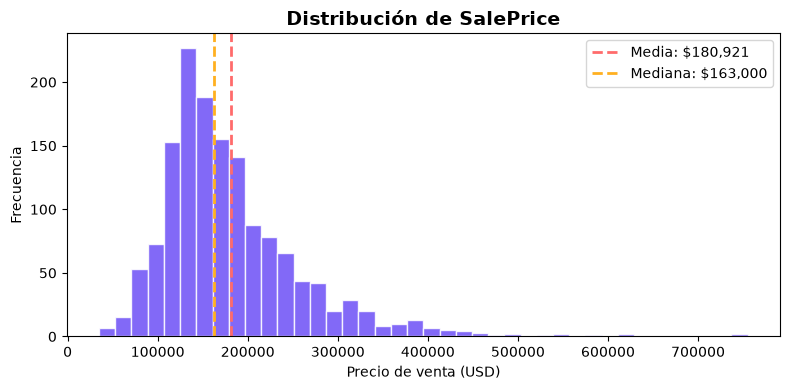

Media:   $     180,921
Mediana: $     163,000
Std:     $      79,443
Mín:     $      34,900
Máx:     $     755,000


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['SalePrice'], bins=40, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.axvline(df['SalePrice'].mean(), color='#FF6B6B', linewidth=2,
           linestyle='--', label=f"Media: ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='#FFB020', linewidth=2,
           linestyle='--', label=f"Mediana: ${df['SalePrice'].median():,.0f}")

ax.set_title('Distribución de SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio de venta (USD)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Media:   ${df["SalePrice"].mean():>12,.0f}')
print(f'Mediana: ${df["SalePrice"].median():>12,.0f}')
print(f'Std:     ${df["SalePrice"].std():>12,.0f}')
print(f'Mín:     ${df["SalePrice"].min():>12,.0f}')
print(f'Máx:     ${df["SalePrice"].max():>12,.0f}')

La distribución tiene una cola hacia la izquierda (*left skew*). Hay pocas casas muy caras que jalan la media hacia arriba. Por eso la mediana es más baja que la media.

---
## PARTE 2. Reporte de reconocimiento

*A partir de aquí trabajan por su cuenta (en equipo). El objetivo no es solo correr los comandos, es interpretar lo que ven y escribir sus hallazgos en las celdas de texto.*

**Entregable:** este mismo notebook, con todas las celdas ejecutadas y los cuadros de interpretación completados.

> **Documentación oficial de pandas:** [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/frame.html)

> Úsenla cuando encuentren un comando que no se explicó en clase.

### 2.1 Primeras y últimas filas: `.head()`, `.tail()`, `.sample()`

Estos tres comandos no se vieron en la presentación, búscalos en la documentación y completa el ejercicio.

| Comando | ¿Qué hace? |
|---|---|
| `df.head(n)` | Muestra las primeras `n` filas (por defecto 5) |
| `df.tail(n)` | Muestra las últimas `n` filas |
| `df.sample(n)` | Muestra `n` filas aleatorias |

In [9]:
# Muestra las primeras 5 filas
df.head(5)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
# Muestra las últimas 5 filas
df.tail(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [11]:
# Muestra 5 filas aleatorias (útil para ver muestras representativas)
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
690,691,120,RM,NaN,4426,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,141000
1394,1395,120,RL,53.0,4045,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,New,Partial,246578
1137,1138,50,RL,54.0,6342,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,94000
1180,1181,60,RL,NaN,11170,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,4,2006,WD,Normal,250000
1176,1177,20,RL,37.0,6951,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,10,2008,WD,Normal,119500


**Interpretación:**

*¿Qué tipo de información tienen las primeras columnas? ¿Hay columnas que a primera vista no entiendes qué representan? Anótalas aquí.*

Las primeras columnas tratan con características que aplican para la mayoría de las propiedades listadas, conforme uno avanza las columnas tratan cualidades que solo algunas propiedades tienen (sótanos, segundos pisos, garages, piscinas, etc.). Las últimas 5 columnas tratan sobre la venta de la propiedad. 

Mientras realizabamos la actividad decidimos buscar que era cada columna, así que a este punto ya sabíamos que eran. Estas son las que nos parecieron más confusas: MSSubClass, MSZoning, LotConfig, MasVnrType, MasVnrArea y Functional.

### 2.2 Tipos de dato y cardinalidad: `.dtypes`, `.nunique()`

`.dtypes` ya lo conocen de `.info()`, pero aquí lo usamos de forma más directa para filtrar variables.
`.nunique()` cuenta cuántos valores únicos tiene cada columna. Es muy útil para detectar columnas casi constantes o IDs disfrazados de variables.

In [12]:
# Valores únicos por columna ordenados de mayor a menor
df.nunique().sort_values(ascending=False)

Id              1460
LotArea         1073
GrLivArea        861
BsmtUnfSF        780
1stFlrSF         753
                ... 
BsmtHalfBath       3
Utilities          2
Street             2
Alley              2
CentralAir         2
Length: 81, dtype: int64

**Interpretación:**

*¿Hay columnas con muy pocos valores únicos (por ejemplo, menos de 5)? ¿Qué tipo de variable podría ser esa? ¿Y columnas con un valor único por fila qué significaría eso?*

Si se encuentran varias columnas con menos de 5 valores unicos:
BsmtHalfBath
Utilities
Street
Alley
CentralAir

La primera columna en realidad no se llega a entender lo que debe representar, pero las demas se entienden mejor, Utilities muy probablemente representa el numero de servicios basicos que tiene la propiedad (Electricidad, Gas, Agua, etc) y como muchas propiedades tienen esas utilidades, entonces se llega a repetir el valor varias veces. CentralAir no se entiende bien lo que debe representar.

No se encuentra ninguna columna con un solo valor unico por fila pero muy probablemente seria util para clasificar propiedades que tengan algun tipo de feature extra, pero eso probablemente se ve descrito por MiscFeature, ya que claramente esta tabla sigue un estandar para poder clasificar la mayoria o si no todas las propiedades.

### 2.3 Análisis de valores faltantes

El conteo absoluto que vimos en la demo no siempre es suficiente, el porcentaje de faltantes es más informativo para decidir qué hacer con cada columna.

In [13]:
# Porcentaje de valores faltantes por columna
nulos / len(df) * 100


Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

**Interpretación:**

*¿Cuáles son las 3 columnas con mayor porcentaje de faltantes? Para una de ellas, busca su descripción en el [data_description.txt](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data) de Kaggle e intenta entender por qué podría tener tantos faltantes. ¿Es un dato realmente ausente o el faltante tiene un significado?*

Las columnas con mayor porcentaje faltante son: PoolQC, MiscFeature y Alley. Tiene sentido que a estas columas les falten datos. En el caso de PoolQC que es la calidad de la alberca, hay muchos datos faltantes porque la mayoría de las casas que no tienen alberca, por lo que NA es una categoría válida, tiene un significado que "falten" datos.

---
## Resumen de hallazgos (conclusión del equipo)

Completen este resumen antes de entregar.

| Pregunta | Respuesta del equipo |
|---|---|
| ¿Cuántas observaciones y variables tiene el dataset? | De acuerdo con el .shape el dataset tiene 1460 observaciones (casas) y 81 variables (columnas) |
| ¿Cuál es la variable objetivo Y? ¿Define clasificación o regresión? | SalePrice es la variable objetiva, definida por regresión dado que nos interesa encontrar un valor numérico. |
| ¿Cuántas columnas tienen valores faltantes? ¿Cuáles son las más críticas? | Hay 19 columnas con valores faltantes. Si medimos cuáles son las más críticas por cantidad de datos faltantes estas serían PoolQC, MiscFeature, Alley y Fence. |
| ¿Hay algo que les llamó la atención o les generó una pregunta? | En un primer momento, nos llamó la atención que hubiera tantos datos "faltantes" o con el valor NA, sin embargo, después de hacer la interpretación, nos dimos cuenta de que el hecho de que el dato estuviera ausente, en realidad tenía un significado. |

In [14]:
# Esto es para responder a la tercera pregunta
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64